# **Statistical Testing + Exploratory Data Analysis**

This notebook contains the initial analysis, along with the statistical testing to work towards answering the critical research questions:

- Which borough is having the most patient visits turning into hospital admissions?
    - In other words, which borough is having the most severe illness cases?

- Which neighborhoods are high in visits & low in admissions, needing the most support?
    - This could possibly be a problem with hospital overflowing, etc.

> !NOTE
> Visits & Admissions are strictly for influenza/pneumonia symptoms, which were large indicators of COVID-19 during this time.


## 1. **Borough Analysis**

mean visit:admissions ratio per borough

### **Statistical Testing:**

ANOVA + Tukey's Post-Hoc Test

Look for statistical significant difference between ratios across boroughs

#### **Pre-check Diagnostics**

- Sample Sizes

- Group Distributions for visit_admissions_ratio

- variance test (Levene's Test)


In [14]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [15]:
# loading in data
path = '../../Data/nyc_dohmh_clean.csv'
df = pd.read_csv(path)

In [16]:
display(df.describe())
print(df.columns)
print(df.dtypes)

,mod_zcta,total_ed_visits,ili_pne_visits,ili_pne_admissions,visit_admissions_ratio
count,7.454806e+06,7.454806e+06,7.454806e+06,7.454806e+06,7.454806e+06
mean,1.083471e+04,5.164867e+01,2.949206e+00,6.076648e-01,6.574632e-02
std,5.664213e+02,3.050447e+01,2.085115e+00,6.994018e-01,3.911197e-02
min,1.000100e+04,6.000000e+00,1.000000e+00,0.000000e+00,7.092199e-03
25%,1.030400e+04,2.800000e+01,1.000000e+00,0.000000e+00,3.571429e-02
50%,1.120500e+04,4.500000e+01,2.000000e+00,0.000000e+00,5.714286e-02
75%,1.136200e+04,7.000000e+01,4.000000e+00,1.000000e+00,8.695652e-02
max,1.169700e+04,1.410000e+02,1.000000e+01,2.000000e+00,1.944444e-01


Index(['date', 'mod_zcta', 'total_ed_visits', 'ili_pne_visits',
       'ili_pne_admissions', 'borough', 'visit_admissions_ratio'],
      dtype='object')
date                       object
mod_zcta                    int64
total_ed_visits             int64
ili_pne_visits              int64
ili_pne_admissions          int64
borough                    object
visit_admissions_ratio    float64
dtype: object


In [17]:
print("Borough sample sizes")
print(df["borough"].value_counts())
print('----------------------')
print("Checking for 0's in visit_admissions_ratio")
print(df["visit_admissions_ratio"].value_counts())

Borough sample sizes
Queens           2434163
Brooklyn         1783777
Manhattan        1653113
The Bronx        1046376
Staten Island     537377
Name: borough, dtype: int64
----------------------
Checking for 0's in visit_admissions_ratio
0.076923    140840
0.066667    136436
0.071429    135128
0.083333    132609
0.090909    132291
             ...  
0.007576       340
0.007463       340
0.007194       340
0.007353       339
0.008333       169
Name: visit_admissions_ratio, Length: 717, dtype: int64


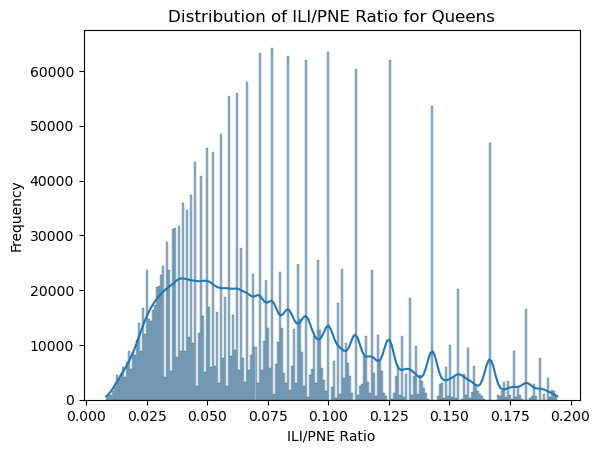

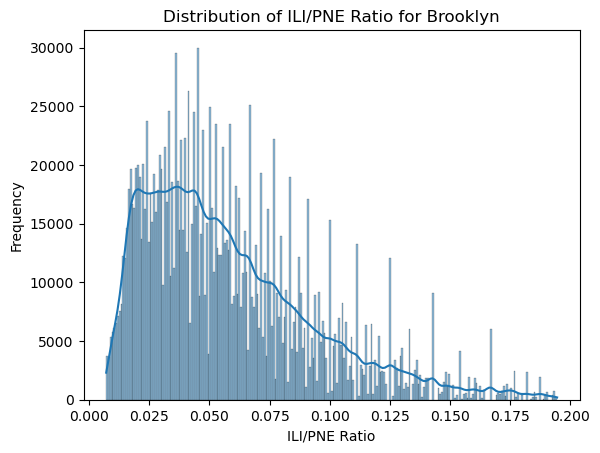

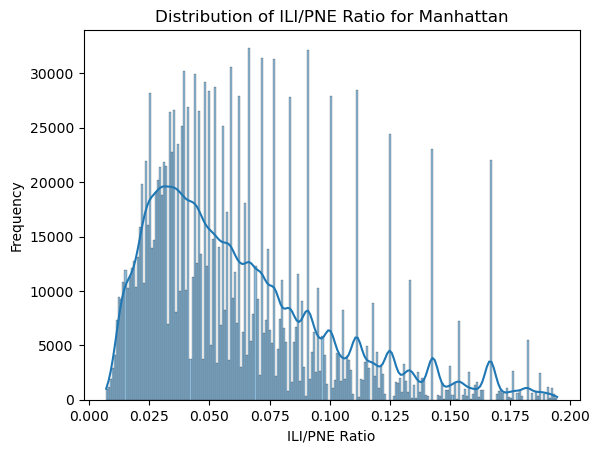

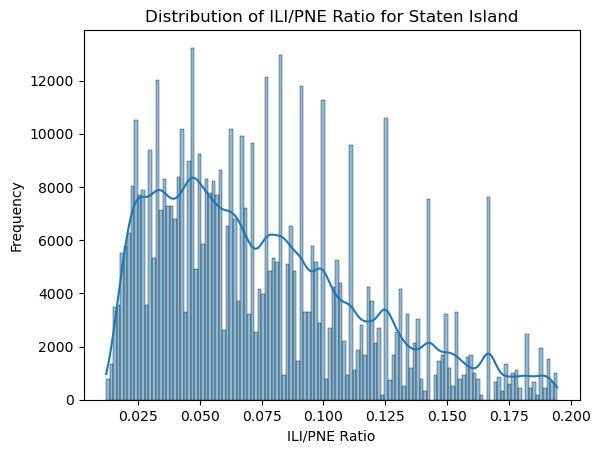

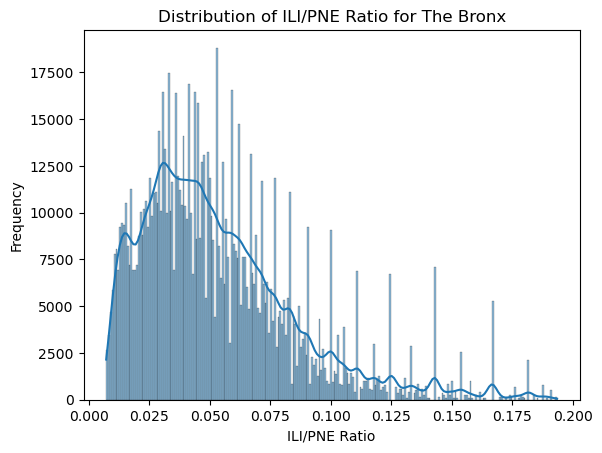

In [18]:
# checking distributions for each borough
boroughs = df["borough"].unique()
for borough in boroughs:
    sns.histplot(df[df["borough"] == borough]["visit_admissions_ratio"], kde=True)
    plt.title(f"Distribution of ILI/PNE Ratio for {borough}")
    plt.xlabel("ILI/PNE Ratio")
    plt.ylabel("Frequency")
    plt.show()

In [19]:
# Variance equality test across the 5 boroughs (Levene's test)
groups = [
    df.loc[df["borough"] == b, "visit_admissions_ratio"].dropna()
    for b in boroughs
]

levene_stat, levene_p = stats.levene(*groups, center="median")

print("Levene's test (H0: all borough variances are equal)")
print(f"Statistic: {levene_stat}")
print(f"P-value:   {levene_p}")

alpha = 0.05
if levene_p < alpha:
    print("Result: Reject H0 — variances differ across boroughs.")
else:
    print("Result: Fail to reject H0 — no significant variance difference detected.")

Levene's test (H0: all borough variances are equal)
Statistic: 29377.842723970243
P-value:   0.0
Result: Reject H0 — variances differ across boroughs.


#### **Diagnostics Summary**

- Pipeline Validation: No 0's in the engineered feature.

- Distribution Check: All 5 boroughs are right-skewed, as expected. 
    - Interpretation: Central Limit Theorem (CLT) dictates that their large *n* size will be observed as normal.

- Variance Test: Levene's Variance Test indicates that there's a statistically significant difference in variance across the groups. 
    - Interpretation: The spread of the data from the columns are statistically significantly unequal.

<br>

<div align='center'>

**As a result of unequal *variances* and *n* sizes, I will use Welch's ANOVA + Games-Howell's Post-Hoc test for best statistical interpretation.**

</div>

<br>

***

# **Statistical Testing**

<div align='center'>

Using Welch's ANOVA & Games-Howell's Post Hoc Test (if ANOVA fails H0) to find statistical significance in the the rate of visits:admissions for each borough.

</div>

## **Welch's ANOVA**

### Hypothesis

H0 = There is no statistically significant difference in the mean visits:admissions ratio between each borough.

H1 = One or more groups have a statistically significant difference in their mean visits:admissions ratio.

### Notes

I expect we will reject the null hypothesis. Although Welch's ANOVA is robust to unequal samples sized and variances, there are large differences here. I will have to validate much of the findings here.

In [24]:
# Quick Pre-checks
print(f"NA's: {df['visit_admissions_ratio'].isna().sum()}")
print('-' * 50)
display(df.describe())
print('-' * 50)
print(df.dtypes)

NA's: 0
--------------------------------------------------


,mod_zcta,total_ed_visits,ili_pne_visits,ili_pne_admissions,visit_admissions_ratio
count,7.454806e+06,7.454806e+06,7.454806e+06,7.454806e+06,7.454806e+06
mean,1.083471e+04,5.164867e+01,2.949206e+00,6.076648e-01,6.574632e-02
std,5.664213e+02,3.050447e+01,2.085115e+00,6.994018e-01,3.911197e-02
min,1.000100e+04,6.000000e+00,1.000000e+00,0.000000e+00,7.092199e-03
25%,1.030400e+04,2.800000e+01,1.000000e+00,0.000000e+00,3.571429e-02
50%,1.120500e+04,4.500000e+01,2.000000e+00,0.000000e+00,5.714286e-02
75%,1.136200e+04,7.000000e+01,4.000000e+00,1.000000e+00,8.695652e-02
max,1.169700e+04,1.410000e+02,1.000000e+01,2.000000e+00,1.944444e-01


--------------------------------------------------
date                       object
mod_zcta                    int64
total_ed_visits             int64
ili_pne_visits              int64
ili_pne_admissions          int64
borough                    object
visit_admissions_ratio    float64
dtype: object


In [23]:
from scipy.stats import f_oneway
import pingouin as pg

# Welch's ANOVA
welch_result = pg.welch_anova(data=df, dv="visit_admissions_ratio", between="borough")

print("Welch's ANOVA Results:")
print("=" * 50)
display(welch_result)

p_val = welch_result["p-unc"].values[0]
f_stat = welch_result["F"].values[0]

print(f"\nF-Statistic: {f_stat:.4f}")
print(f"P-value:     {p_val}")

if p_val < alpha:
    print("\nResult: Reject H0 — At least one borough has a statistically significant difference in mean visit:admissions ratio.")
else:
    print("\nResult: Fail to reject H0 — No significant difference detected between boroughs.")

Welch's ANOVA Results:


,Source,ddof1,ddof2,F,p-unc,np2
0,borough,4,2.521195e+06,109611.152474,0.0,0.054606



F-Statistic: 109611.1525
P-value:     0.0

Result: Reject H0 — At least one borough has a statistically significant difference in mean visit:admissions ratio.


In [26]:
# Games-Howell Post-Hoc Test
games_howell_result = pg.pairwise_gameshowell(data=df, dv="visit_admissions_ratio", between="borough")

print("Games-Howell Post-Hoc Test Results:")
print("=" * 50)
display(games_howell_result)
print('-' * 50)

mean_ratio_boro = df.groupby('borough')['visit_admissions_ratio'].mean().sort_values(ascending=False)
display(mean_ratio_boro)

Games-Howell Post-Hoc Test Results:


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,Brooklyn,Manhattan,0.058077,0.062575,-0.004498,0.000040,-112.711587,3.360518e+06,0.0,-0.122030
1,Brooklyn,Queens,0.058077,0.076711,-0.018633,0.000037,-498.757197,4.101144e+06,0.0,-0.480937
2,Brooklyn,Staten Island,0.058077,0.075321,-0.017244,0.000063,-273.718861,7.843214e+05,0.0,-0.465111
3,Brooklyn,The Bronx,0.058077,0.053408,0.004670,0.000041,113.289811,2.364074e+06,0.0,0.136032
4,Manhattan,Queens,0.062575,0.076711,-0.014135,0.000040,-356.164881,3.703265e+06,0.0,-0.354341
5,Manhattan,Staten Island,0.062575,0.075321,-0.012745,0.000064,-197.895255,8.485827e+05,0.0,-0.325273
6,Manhattan,The Bronx,0.062575,0.053408,0.009168,0.000043,211.532927,2.491771e+06,0.0,0.254324
7,Queens,Staten Island,0.076711,0.075321,0.001390,0.000063,22.112241,7.807154e+05,0.0,0.033800
8,Queens,The Bronx,0.076711,0.053408,0.023303,0.000041,568.300891,2.488519e+06,0.0,0.604654
9,Staten Island,The Bronx,0.075321,0.053408,0.021913,0.000065,335.961879,8.725596e+05,0.0,0.612306


--------------------------------------------------


borough
Queens           0.076711
Staten Island    0.075321
Manhattan        0.062575
Brooklyn         0.058077
The Bronx        0.053408
Name: visit_admissions_ratio, dtype: float64